# Linear Regression — House Price Prediction
### Abrar Jawad | June 2026

---

## What This Notebook Is

This is the ML phase of my house price analysis. Project 02 was pure EDA —
exploring the data, finding correlations, understanding distributions. Now I'm
using those findings to actually build a model that predicts house prices.

I'm using the same Kaggle dataset: House Prices: Advanced Regression Techniques
(1,460 houses, 81 features). The target variable is SalePrice.

This is my first ever ML model.

## Why Linear Regression First

Linear regression is the foundation of supervised ML. Before trees, forests,
or neural networks, you need to understand the simplest case — fitting a line
through data to make predictions. Everything else builds on top of this.

## What I Already Know Going In

From Project 02 EDA, I already know which features correlate most with SalePrice:
- OverallQual (r = 0.791) — strongest predictor
- TotalSF (r = 0.779) — engineered feature
- GrLivArea (r = 0.709)
- GarageCars (r = 0.640)
- GarageArea (r = 0.623)

So feature selection isn't guesswork here — it's backed by prior analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
df = pd.read_csv("../data/raw/train.csv")
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Selecting Features and Target


In [3]:
features = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt']
df_model = df[features + ['SalePrice']].dropna()

x = df_model[features]
y = df_model['SalePrice']

print(x.shape)
print(y.shape)

(1460, 5)
(1460,)


## Train_Test Split


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)

(1168, 5)
(292, 5)


## Training the Model


In [5]:
model = LinearRegression()
model.fit(x_train, y_train)

print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

Intercept: -694533.3581041215
Coefficients: [   48.80980119 20392.51300101    25.36531866 15144.23720351
   315.92335034]


## Making Predictions


In [6]:
y_pred = model.predict(x_test)

print(y_pred[:5])
print(y_test.values[:5])

[142114.23396224 293935.1408129  122246.69425313 179899.2465417
 288653.82881166]
[154500 325000 115000 159000 315500]


## Evaluating Performance

In [7]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print(f"MAE: {mae:.0f}")
print(f"RMSE: {rmse:.0f}")
print(f"R²: {r2:.4f}")

MAE: 25415
RMSE: 39763
R²: 0.7939


## Actual vs Predicted Plot

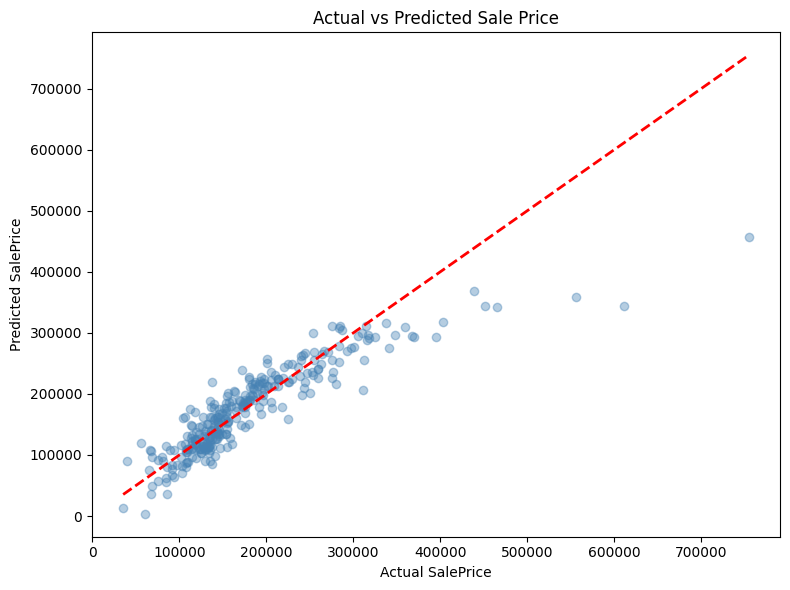

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted Sale Price")
plt.tight_layout()
plt.savefig('../visuals/lr_actual_vs_predicted.png', dpi=150)
plt.show()

## Linear Regression — What I Found

### Model & Features
I used 5 features: GrLivArea, OverallQual, TotalBsmtSF, GarageCars, and YearBuilt.
These were chosen based on the correlation heatmap from Project 02 EDA — I already
knew these were the strongest predictors before building the model.

### Coefficients — What the Model Learned
The model assigned the highest coefficient to OverallQual (~$20,392 per quality point).
This matched exactly what EDA showed — OverallQual had the highest correlation with
SalePrice (r = 0.791). The EDA predicted this before I even touched scikit-learn.

Other coefficients made real-world sense too:
- Each extra sq ft of living area adds ~$49
- Each extra garage car space adds ~$15k
- Each newer year built adds ~$316

### Evaluation Numbers
- MAE: $25,415 — on average, my predictions are off by ~$25k per house
- RMSE: $39,763 — noticeably higher than MAE, which means a few houses have
  very large errors dragging this up
- R²: 0.794 — the model explains 79.4% of the variation in house prices
  using just 5 features. The remaining 20.6% is things the model couldn't capture.

### What the Scatter Plot Showed
Dots clustered well around the perfect prediction line up to ~$300k. Beyond that,
the model consistently underpredicted — almost all expensive houses were below
the red line. The worst case was a house that actually sold for $750k but the
model predicted $460k — a $290k error on a single house. There was also one
house predicted at nearly $0, likely an outlier with unusual feature values.

The gap between RMSE and MAE is explained by exactly these extreme cases.

### Main Limitation
The model works well in the middle but struggles at the extremes. This is a known
limitation of linear regression on skewed price data. The fix is to train on
log(SalePrice) instead of raw SalePrice — the same log transform I applied in
Project 02. That's the next improvement to try.

## Improvement — Log Transformation of Target Variable

The baseline model struggled with expensive houses — consistently underpredicting
them. This is because SalePrice is right-skewed. Training on log(SalePrice)
instead of raw SalePrice compresses the extreme values and makes the target
more symmetric. After predictions, we reverse the log to get back to dollars.

In [10]:
y_log = np.log1p(df_model['SalePrice'])

y_log_train, y_log_test = train_test_split(y_log, test_size=0.2, random_state=42)

log_model = LinearRegression()
log_model.fit(x_train, y_log_train)

y_log_pred = log_model.predict(x_test)
y_pred_actual = np.expm1(y_log_pred)

mae_log = metrics.mean_absolute_error(y_test, y_pred_actual)
mse_log = metrics.mean_squared_error(y_test, y_pred_actual)
rmse_log = np.sqrt(mse_log)
r2_log = metrics.r2_score(y_test, y_pred_actual)

print("\nLog-Transformed Model Performance:")
print(f"Log Model MAE:  {mae_log:,.0f}")
print(f"Log Model RMSE: {rmse_log:,.0f}")
print(f"Log Model R²:   {r2_log:.4f}")

print("\nBaseline Model Performance:")
print(f"Baseline MAE:  {mae:,.0f}")
print(f"Baseline RMSE: {rmse:,.0f}")
print(f"Baseline R²:   {r2:.4f}")


Log-Transformed Model Performance:
Log Model MAE:  20,742
Log Model RMSE: 31,905
Log Model R²:   0.8673

Baseline Model Performance:
Baseline MAE:  25,415
Baseline RMSE: 39,763
Baseline R²:   0.7939


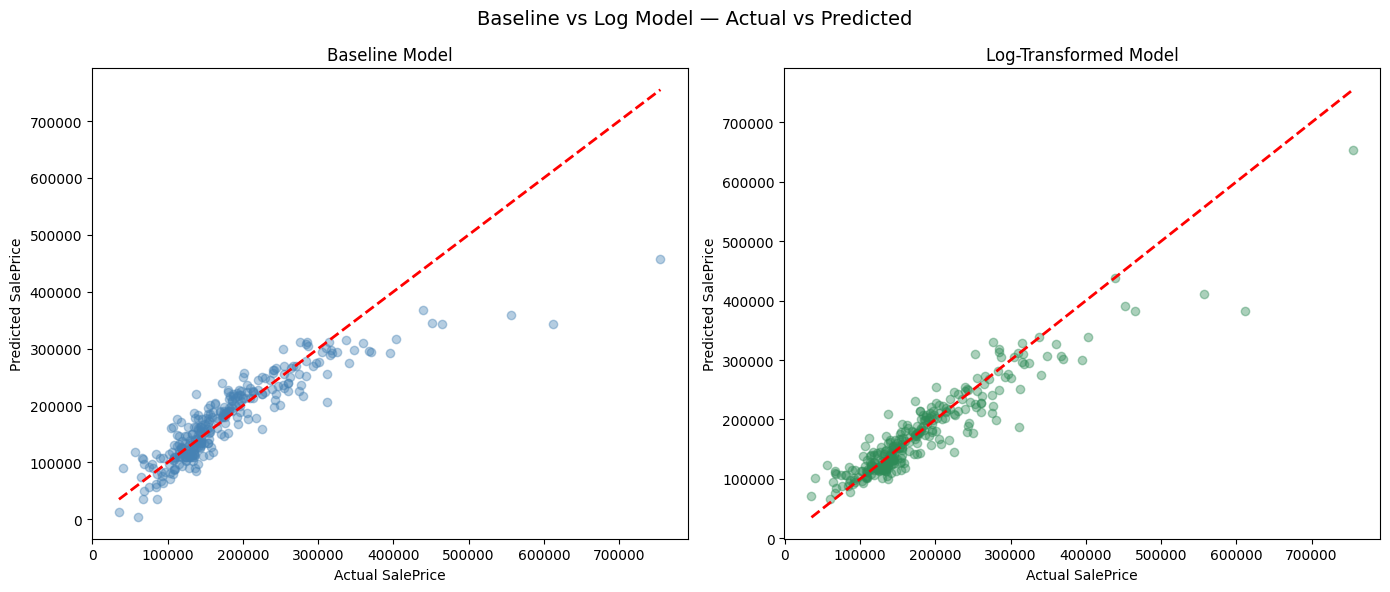

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel("Actual SalePrice")
axes[0].set_ylabel("Predicted SalePrice")
axes[0].set_title("Baseline Model")

axes[1].scatter(y_test, y_pred_actual, alpha=0.4, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel("Actual SalePrice")
axes[1].set_ylabel("Predicted SalePrice")
axes[1].set_title("Log-Transformed Model")

plt.suptitle("Baseline vs Log Model — Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.savefig('../visuals/lr_baseline_vs_log.png', dpi=150)
plt.show()

## Improvement — Log Transformation Results

### What I Did and Why
The baseline model consistently underpredicted expensive houses because SalePrice
is right-skewed. The fix was the same log transform from Project 02 — train on
log(SalePrice) instead of raw prices, then reverse it with expm1() after
prediction. No new features, no new algorithm — just a smarter target variable.

### Results Comparison
| Metric | Baseline | Log Model | Improvement |
|--------|----------|-----------|-------------|
| MAE    | $25,415  | $20,742   | -$4,673     |
| RMSE   | $39,763  | $31,905   | -$7,858     |
| R²     | 0.7939   | 0.8673    | +0.073      |

RMSE improved more than MAE because the log transform specifically compressed
the large outlier errors that were punishing RMSE the most.

### What the Plot Showed
The green plot is visibly tighter around the red line. The near-zero prediction
from the baseline disappeared entirely — log scale has a natural floor that
prevents nonsensical predictions. The $750k house went from a $290k error down
to roughly $100k. Expensive houses are no longer systematically underpredicted
— dots above $300k are now balanced around the line instead of all falling below it.

### What's Still Missing
The model still struggles beyond $400k. Two reasons:
- Only 5 features — more correlated columns would help
- Linear regression assumes a straight line relationship. In reality a house
  with both high quality AND large area is worth disproportionately more than
  either factor alone. Linear regression can't capture that interaction.
  More powerful algorithms like Random Forests can — that's next.